In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()

# Get uploaded filename
filename = next(iter(uploaded))

# Read CSV
df = pd.read_csv(filename)

# Clean column names
df.columns = df.columns.str.strip()

print(df.head())

Saving Dataset .csv to Dataset  (1).csv
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La,

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
print('libraries are imported')

libraries are imported


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [ ]:
df.drop(columns=[
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose',
    'Currency'
], inplace=True)

In [ ]:
print(df.isnull().sum())

Country Code            0
City                    0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [ ]:
df['Cuisines']= df['Cuisines'].fillna('No detail')

In [ ]:
cols= ['Has Online delivery','Has Table booking','Switch to Online booking']
for col in cols:
  if col in df.columns:
    df[col] =df[col].map({'Yes':1,'No':0})

In [ ]:
df.select_dtypes(include='object').columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
y = df['Aggregate rating']
X = df.drop('Aggregate rating', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
print("MSE:", mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)
print("R2 Score:", r2_lr)

MSE: 1.300411582428231
R2 Score: 0.42866901894209664


In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree MSE:",
      mean_squared_error(y_test, y_pred_dt))

print("Decision Tree R2:",
      r2_score(y_test, y_pred_dt))

Decision Tree MSE: 0.05363160648874934
Decision Tree R2: 0.9764371536173858


In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest MSE:",
      mean_squared_error(y_test, y_pred_rf))

print("Random Forest R2:",
      r2_score(y_test, y_pred_rf))

Random Forest MSE: 0.02905998011512295
Random Forest R2: 0.9872326060663854


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
13                 Votes    0.899916
11          Rating color    0.080705
12           Rating text    0.008707
3               Latitude    0.002896
2              Longitude    0.002840
4               Cuisines    0.002328
5   Average Cost for two    0.001565
7    Has Online delivery    0.000353
1                   City    0.000303
10           Price range    0.000220


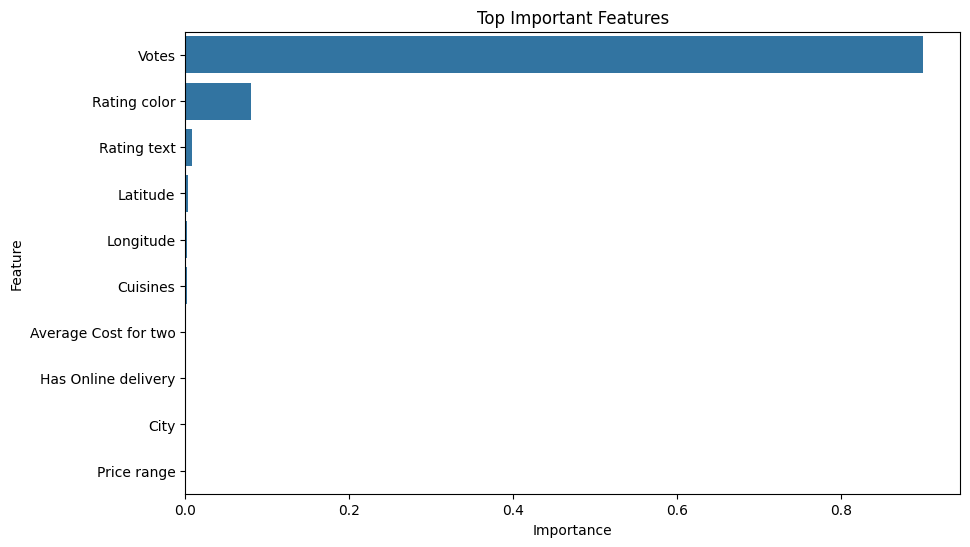

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top Important Features")
plt.show()

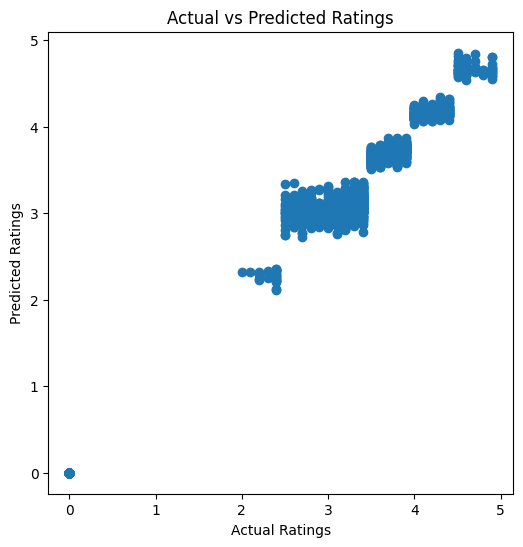

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()